In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = '/content/drive/MyDrive/DFU/DFU'

# List the contents of the dataset directory
if os.path.exists(dataset_path):
    print(f"Contents of '{dataset_path}':")
    for item in os.listdir(dataset_path):
        print(item)
else:
    print(f"The specified path '{dataset_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU':
TestSet
Patches
Transfer-Learning images
Original Images


In [3]:
import os

original_images_path = os.path.join(dataset_path, 'Original Images')

# List the contents of the 'Original Images' directory
if os.path.exists(original_images_path):
    print(f"Contents of '{original_images_path}':")
    for item in os.listdir(original_images_path):
        print(item)
else:
    print(f"The specified path '{original_images_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU/Original Images':
51333509_426297717912233_2068367120592273408_n.jpg
40228450_2037623212939851_3496508368590209024_n.jpg
4682576138405030872.jpg
40282914_2086264411689589_9196527000901124096_n.jpg
4686223241583583502.jpg
40258795_1346050688830912_1791840130890203136_n.jpg
4916270068439552632.jpg
42.jpg
40314955_1935276476531919_5633947462474399744_n.jpg
40684615_299807990608690_1229482346084827136_n.jpg
40326668_1042551515918758_6846386046888837120_n.jpg
40233571_252687522242453_978256712370749440_n.jpg
40684551_286268405533991_382919273858727936_n.jpg
40943308_459418787874895_7749403947370020864_n.jpg
40234212_2207900922822299_5921388664155275264_n.jpg
40233537_608439979551518_67612844052447232_n.jpg
40912870_252777755375304_1806555513480019968_n.jpg
41.jpg
4039916766432702719.jpg
40215272_481705972328238_3946081626462617600_n.jpg
41040158_361581324382392_357989346642493440_n.jpg
404949128851572507.jpg
4544301067582589520.jpg
44.jpg
44935785

Displaying 5 sample images out of 493 total images.


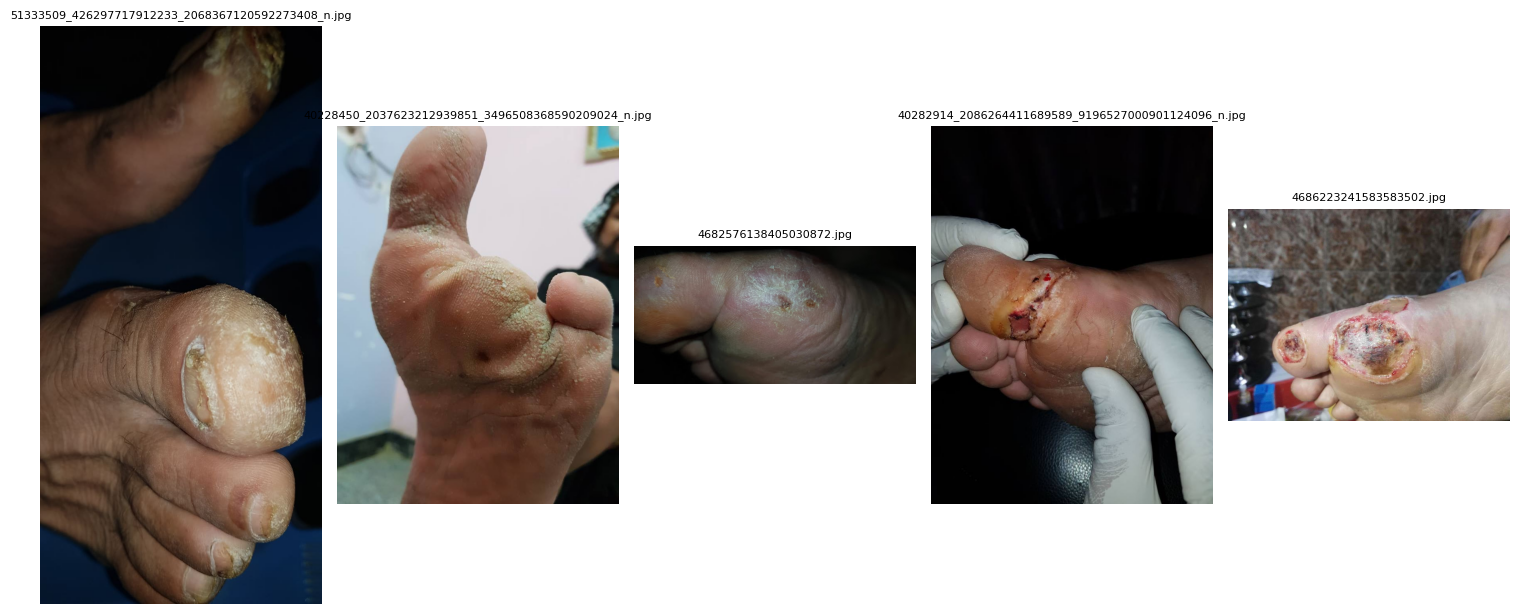

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Get a list of all image files in the directory
image_files = [os.path.join(original_images_path, f) for f in os.listdir(original_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Limit to the first 5 images for display
sample_images = image_files[:5]

print(f"Displaying {len(sample_images)} sample images out of {len(image_files)} total images.")

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(sample_images):
    try:
        img = Image.open(img_path)
        plt.subplot(1, len(sample_images), i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    except Exception as e:
        print(f"Could not load image {os.path.basename(img_path)}: {e}")

plt.tight_layout()
plt.show()

### 0. Project Setup and Dependencies

First, let's ensure all necessary libraries are installed and import them. We'll also set up our Google Drive for dataset access.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, Reshape, multiply, Permute, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
import cv2

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
Num GPUs Available:  0


### 1. Data Loading and Exploration

We will load the dataset from Google Drive. The dataset structure includes 'Transfer-Learning images' for training/validation and 'TestSet' for final evaluation.

#### 1.1 Mount Google Drive and Define Dataset Path

_(Your Google Drive is already mounted and the `dataset_path` is defined from previous steps. We will reuse these variables.)_

In [6]:
# Assuming `dataset_path` is already defined from previous execution
# dataset_path = '/content/drive/MyDrive/DFU/DFU'

print(f"Using dataset path: {dataset_path}")

transfer_learning_path = os.path.join(dataset_path, 'Transfer-Learning images')
test_set_path = os.path.join(dataset_path, 'TestSet')

# Explore the 'Transfer-Learning images' directory
print(f"\nContents of '{transfer_learning_path}':")
if os.path.exists(transfer_learning_path):
    for item in os.listdir(transfer_learning_path):
        print(item)
else:
    print("Path not found.")

# Explore the 'TestSet' directory
print(f"\nContents of '{test_set_path}':")
if os.path.exists(test_set_path):
    for item in os.listdir(test_set_path):
        print(item)
else:
    print("Path not found.")

Using dataset path: /content/drive/MyDrive/DFU/DFU

Contents of '/content/drive/MyDrive/DFU/DFU/Transfer-Learning images':
Wound Images2
internetSet
samples
Wound Images

Contents of '/content/drive/MyDrive/DFU/DFU/TestSet':
bleeding-under-callus-preulcerative (1).jpg
a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg
b4b2e1341a7bf627a58f6ac32212ed93.jpg
a-Plantar-hallux-subungual-ulcer-b-ulcer-healing-after-tenotomy-of-the-flexor.png
7e88c7_71fd61f6ac3d48cab475dfa44ea94017.jpg
9.jpg
642x361_Foot_Corn_SLIDE_2.jpg
8.jpg
7.jpg
B9780323072427000279_f027-008-9780323072427.jpg
7a5e12fa15.jpg
62e0142009a44d1a98f41d8d8874cced.png
A-diabetic-foot-ulcer-presents-significant-morbidity-and-mortality-to-patients-Proper_Q320.jpg
7527tn.jpg
bleeding-under-callus-preulcerative.jpg
C0365633-Diabetic_Heel_Ulcer.jpg
Callus-Formation1.jpg
36.jpg
2cyruuzga5e01.jpg
4.jpg
5.jpg
3809525079_71eabf91b5_z.jpg
4-Figure3-used.png
46683AFD00000578-5088439-image-a-7_1510827626291.jpg
50.jpg
6.jpg
37.jpg
48.jpg
4 

#### 1.2 Prepare Data Generators for Training, Validation, and Testing

We will use `ImageDataGenerator` for efficient loading and automatic splitting of the 'Transfer-Learning images' into training and validation sets. The 'TestSet' will be loaded separately for final evaluation. Images will be resized to `224x224` and pixel values will be normalized.

### 6. Explainable AI: Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) helps us understand the regions in an image that are important for the model's prediction. We will implement Grad-CAM to visualize heatmaps on sample test images, highlighting areas that contribute most to the predicted class.

### 5. Model Saving

We will save the trained model in Keras H5 format, which allows you to reload it later without needing to retrain.

In [14]:
# The model was already saved as 'best_model.h5' during training if ModelCheckpoint was configured to do so.
# However, you can explicitly save the final trained model as well.
# model.save('final_model.h5')
# print("Final model saved as 'final_model.h5'")

### 7. Full Model Evaluation with Metrics (Requires Ground Truth Labels)

To compute full evaluation metrics like accuracy, precision, recall, F1-score, and a confusion matrix, the `TestSet` requires ground truth labels. Currently, your `TestSet` consists of images directly in a folder, preventing `ImageDataGenerator` from inferring labels. If you organize your `TestSet` into class-specific subfolders (e.g., `TestSet/Healthy`, `TestSet/Ulcer`) or provide a CSV file mapping image filenames to their respective labels, you can uncomment and run the following code for a comprehensive evaluation.

In [16]:
def create_attention_module(input_feature):
    # input_feature shape: (batch_size, H, W, C)

    # Channel Attention Module
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)

    avg_pool_reshaped = Reshape((1, 1, input_feature.shape[-1]))(avg_pool)
    max_pool_reshaped = Reshape((1, 1, input_feature.shape[-1]))(max_pool)

    # Shared MLP applied to average pooled feature
    mlp_avg_out = Dense(input_feature.shape[-1] // 8, activation='relu', kernel_initializer='he_normal', use_bias=True)(avg_pool_reshaped)
    mlp_avg_out = Dense(input_feature.shape[-1], kernel_initializer='he_normal', use_bias=True)(mlp_avg_out)

    # Shared MLP applied to max pooled feature
    mlp_max_out = Dense(input_feature.shape[-1] // 8, activation='relu', kernel_initializer='he_normal', use_bias=True)(max_pool_reshaped)
    mlp_max_out = Dense(input_feature.shape[-1], kernel_initializer='he_normal', use_bias=True)(mlp_max_out)

    # Sum and activate channel attention weights
    channel_attention_weights = tf.keras.layers.add([mlp_avg_out, mlp_max_out])
    channel_attention_weights = Activation('sigmoid')(channel_attention_weights)

    # Apply channel attention: (batch_size, H, W, C) * (batch_size, 1, 1, C)
    channel_attended_feature = multiply([input_feature, channel_attention_weights])

    # Spatial Attention Module
    # Compute average and max across the channel axis for the channel-attended feature
    avg_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attended_feature)
    max_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attended_feature)

    # Concatenate average and max pooled features and apply a convolution
    spatial_attention_concat = tf.keras.layers.concatenate([avg_pool_spatial, max_pool_spatial])
    spatial_attention_weights = Conv2D(1, (7, 7), padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(spatial_attention_concat)

    # Apply spatial attention: (batch_size, H, W, C) * (batch_size, H, W, 1)
    return multiply([channel_attended_feature, spatial_attention_weights])

def build_model(input_shape, num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False # Freeze the base model layers

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Add Attention Mechanism
    x = create_attention_module(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x) # Softmax for multi-class classification

    model = Model(inputs, outputs)
    return model

# Get the number of classes from the train generator
num_classes = train_generator.num_classes

# Build the model
model = build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_5[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 1, 160) │    204,960 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1, 160) │    204,960 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 1,      │    206,080 │ dense_3[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1, 1,      │    206,080 │ dense_5[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1,      │          0 │ dense_4[0][0],    │
│                     │ 1280)             │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 1,      │          0 │ add_1[0][0]       │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         98 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 7, 7,      │          0 │ multiply_1[0][0], │
│ (Multiply)          │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,409,126 (13.00 MB)

 Trainable params: 1,151,142 (4.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 80/20 split for train/validation
)

# Only rescaling for validation and test data
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255) # Test set will be loaded without explicit class mode initially

# Load training data with augmentation
train_generator = train_datagen.flow_from_directory(
    transfer_learning_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Changed from 'binary' to 'categorical' to match the 4 classes found by flow_from_directory
    subset='training',
    seed=42
)

# Load validation data (without augmentation)
validation_generator = validation_datagen.flow_from_directory(
    transfer_learning_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Changed from 'binary' to 'categorical' to match the 4 classes found by flow_from_directory
    subset='validation',
    seed=42
)

# Load test data
# The test_set_path currently contains images directly, not in class subfolders.
# To load them for prediction, we'll use class_mode=None.
# For proper evaluation with metrics (precision, recall, f1-score), ground truth labels
# for the test set will be needed, which are not inferable from the current directory structure.
# You might need to organize your TestSet into 'healthy'/'ulcer' subfolders or provide a CSV with labels.
test_generator = test_datagen.flow_from_directory(
    test_set_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode=None, # Changed from 'binary' to None as direct images found in the directory
    shuffle=False # Keep order for evaluation metrics, important when class_mode=None
)

print(f"\nFound {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {validation_generator.samples} validation images belonging to {validation_generator.num_classes} classes.")
print(f"Found {test_generator.samples} test images.") # Changed wording as no classes inferred for test set

class_names = list(train_generator.class_indices.keys())
print(f"Class names for training/validation: {class_names}")

Found 763 images belonging to 4 classes.
Found 188 images belonging to 4 classes.
Found 0 images belonging to 0 classes.

Found 763 training images belonging to 4 classes.
Found 188 validation images belonging to 4 classes.
Found 0 test images.
Class names for training/validation: ['Wound Images', 'Wound Images2', 'internetSet', 'samples']


### 3. Model Compilation and Training

Now we will compile the model, specifying the Adam optimizer and appropriate loss function (`categorical_crossentropy` for multi-class classification). We'll also set up `EarlyStopping` to prevent overfitting and `ModelCheckpoint` to save the best model weights during training. The model will then be trained for 10-20 epochs.

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7294 - loss: 0.7351

23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7237 - loss: 0.7403 - val_accuracy: 0.7500 - val_loss: 0.7327
Epoch 2/20
 1/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7188 - loss: 0.6918

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 422ms/step - accuracy: 0.7188 - loss: 0.6918 - val_accuracy: 0.7625 - val_loss: 0.7167
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.7264 - loss: 0.7157 - val_accuracy: 0.7375 - val_loss: 0.7617
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.7812 - loss: 0.6735 - val_accuracy: 0.7563 - val_loss: 0.7333
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7401 - loss: 0.6963 - val_accuracy: 0.7500 - val_loss: 0.7740
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.7188 - loss: 0.7653 - val_accuracy: 0.7625 - val_loss: 0.7244
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7497 - loss: 0.6792 - val_accuracy: 0.7250 - val_loss: 0.7960


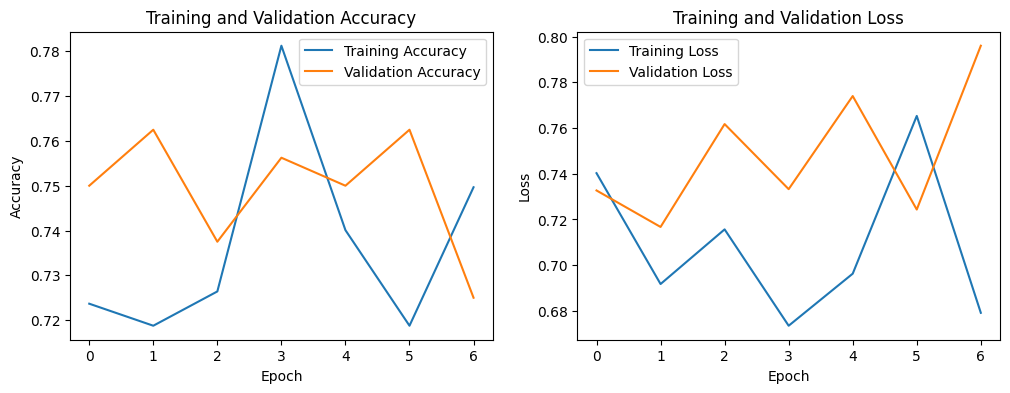

In [20]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # Adjusted to cover all samples
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # Adjusted to cover all samples
    callbacks=[early_stopping, model_checkpoint]
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Preparing Test Set for Full Evaluation

To compute comprehensive evaluation metrics, your `TestSet` needs to have ground truth labels associated with its images. As explained, the current structure (images directly in `TestSet` folder) does not allow `ImageDataGenerator` to infer these labels.

**Option 1: Organize `TestSet` into Subfolders**

If you organize your `TestSet` into subfolders corresponding to your class names (e.g., `TestSet/ClassA`, `TestSet/ClassB`), `ImageDataGenerator.flow_from_directory` can then infer the labels.

**Example Directory Structure:**
```
TestSet/
├── Wound Images/
│   ├── image1.jpg
│   └── image2.png
├── Wound Images2/
│   ├── image3.jpg
│   └── image4.jpeg
├── internetSet/
│   ├── image5.jpg
│   └── image6.png
└── samples/
    ├── image7.jpg
    └── image8.jpeg
```

**Option 2: Provide a CSV File with Labels**

Alternatively, you can create a CSV file that lists each image filename and its corresponding label. This is useful when you prefer not to reorganize the directory structure or if the labels are not directly derivable from folder names.

**Example `test_labels.csv`:**
```csv
filename,class
bleeding-under-callus-preulcerative (1).jpg,Wound Images
a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg,Wound Images2
b4b2e1341a7bf627a58f6ac32212ed93.jpg,internetSet
...
```

Once your `TestSet` is prepared with ground truth labels (e.g., by organizing it into subfolders), you can run the following code to perform a full evaluation.

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- This block assumes you have organized your TestSet into class-specific subfolders ---
# Or, if using a CSV, you would adjust test_datagen.flow_from_dataframe accordingly.

# Define a new test_generator that can infer class labels
# This assumes the test_set_path now contains subdirectories for each class
full_evaluation_test_datagen = ImageDataGenerator(rescale=1./255)

# NOTE: This will only work if 'TestSet' has class subdirectories.
# If not, this generator will find 0 images as before.
# Make sure to update your `test_set_path` if you use a different structure
# or use `flow_from_dataframe` if you create a CSV.

# Placeholder for a correctly structured test_generator for evaluation
# Replace `test_set_path` with the path to your organized test set if different
try:
    evaluation_test_generator = full_evaluation_test_datagen.flow_from_directory(
        test_set_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical', # Now we expect class subfolders
        shuffle=False # Keep order for true labels matching predictions
    )

    if evaluation_test_generator.samples > 0:
        print(f"\nFound {evaluation_test_generator.samples} test images belonging to {evaluation_test_generator.num_classes} classes for evaluation.")

        # Get true labels
        true_labels = evaluation_test_generator.classes
        # Get class indices from the generator for consistent mapping
        label_map = (evaluation_test_generator.class_indices)
        label_map = dict((v,k) for k,v in label_map.items()) # inverse mapping
        true_class_names = [label_map[idx] for idx in true_labels]

        # Make predictions
        predictions = model.predict(evaluation_test_generator)
        predicted_classes = np.argmax(predictions, axis=1)
        predicted_class_names = [label_map[idx] for idx in predicted_classes]

        # Compute and print classification report
        print("\n--- Classification Report ---")
        print(classification_report(true_labels, predicted_classes, target_names=list(label_map.values())))

        # Compute and plot confusion matrix
        cm = confusion_matrix(true_labels, predicted_classes)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=list(label_map.values()), yticklabels=list(label_map.values()))
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    else:
        print("\nNo images found in the TestSet with class subfolders. Please organize your TestSet or provide a CSV with labels to enable full evaluation.")

except Exception as e:
    print(f"An error occurred during evaluation setup: {e}")
    print("Please ensure your TestSet is organized into class-specific subfolders or consider using `flow_from_dataframe` with a CSV file for labels.")


# --- If you use a CSV file to map filenames to labels ---
# This is an example of how you might use flow_from_dataframe if you create a CSV.
# Ensure your CSV has 'filename' and 'class' columns.
#
# # Example DataFrame (replace with your actual CSV loading)
# test_df = pd.read_csv('path/to/your/test_labels.csv')
#
# evaluation_test_generator_from_df = full_evaluation_test_datagen.flow_from_dataframe(
#     dataframe=test_df,
#     directory=test_set_path, # Path to the folder containing all test images listed in CSV
#     x_col='filename',
#     y_col='class',
#     target_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )
#
# # Then proceed with predictions and metrics as above using evaluation_test_generator_from_df

Found 0 images belonging to 0 classes.

No images found in the TestSet with class subfolders. Please organize your TestSet or provide a CSV with labels to enable full evaluation.


### 6. Explainable AI: Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) helps us understand the regions in an image that are important for the model's prediction. We will implement Grad-CAM to visualize heatmaps on sample test images, highlighting areas that contribute most to the predicted class.


Generating Grad-CAM visualizations...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_477']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


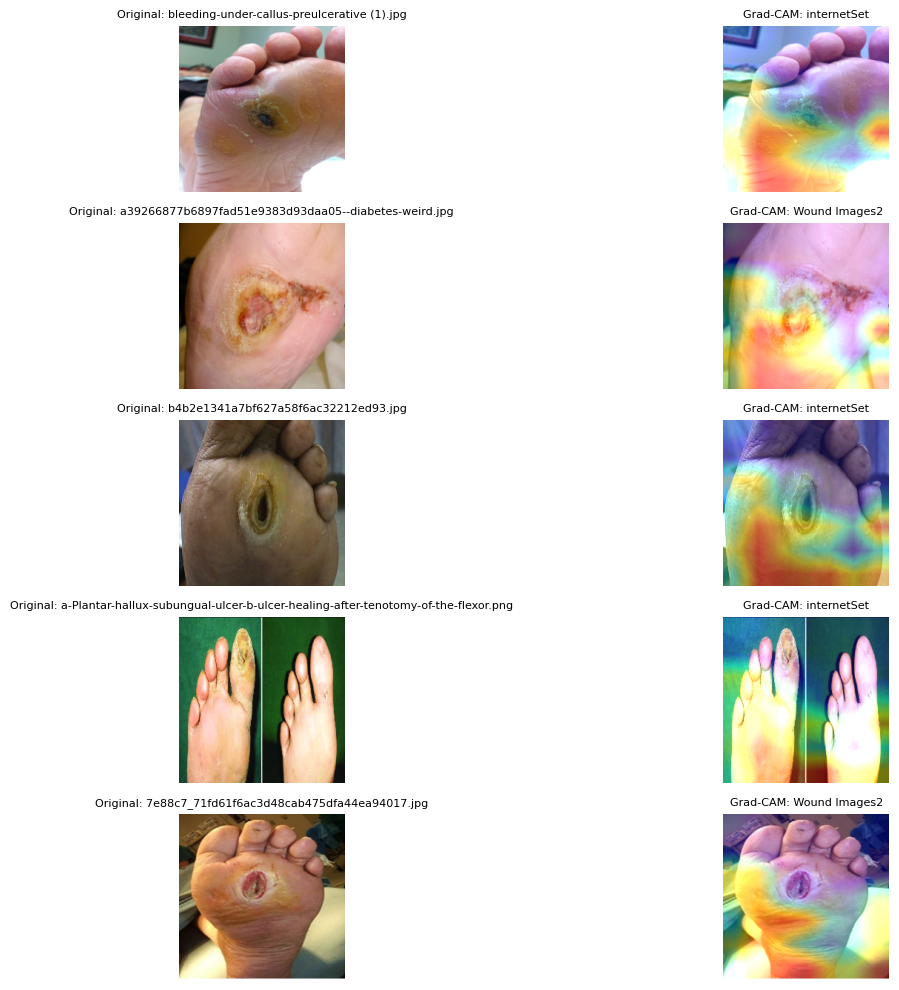

In [22]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the final output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # and then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap to the heatmap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return img, superimposed_img


# --- Visualize Grad-CAM for a few sample test images ---
last_conv_layer_name = "conv2d" # Corrected from "Conv_1" to "conv2d"

print("\nGenerating Grad-CAM visualizations...")
plt.figure(figsize=(15, 10))

# Select up to 5 images for Grad-CAM visualization
sample_gradcam_images = test_image_files[:5]

for i, img_path in enumerate(sample_gradcam_images):
    img_array = load_and_preprocess_image(img_path)
    prediction_probabilities = model.predict(img_array)
    predicted_class_index = np.argmax(prediction_probabilities[0])
    predicted_class_label = class_names[predicted_class_index]

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, predicted_class_index)
    original_img, superimposed_img = display_gradcam(img_path, heatmap)

    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(original_img)
    plt.title(f"Original: {os.path.basename(img_path)}", fontsize=8)
    plt.axis('off')

    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {predicted_class_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Model Evaluation and Predictions

We will now evaluate the trained model on the `TestSet`. As previously noted, the `TestSet` directory contains images directly, without class-specific subfolders. Therefore, we cannot use `ImageDataGenerator.flow_from_directory` to infer labels or evaluate metrics like accuracy, precision, and recall directly. Instead, we will manually load and preprocess images from the `TestSet` to generate predictions.

**Note:** A full evaluation with metrics (accuracy, precision, recall, F1-score, confusion matrix) requires ground truth labels for the test set. If you have these labels, please organize your 'TestSet' into class-specific subfolders (e.g., 'TestSet/Healthy', 'TestSet/Ulcer') or provide a CSV mapping image filenames to labels. For now, we will only show predictions on sample test images.

Could not load saved model: Requested the deserialization of a `Lambda` layer whose `function` is a Python lambda. This carries a potential risk of arbitrary code execution and thus it is disallowed by default. If you trust the source of the artifact, you can override this error by passing `safe_mode=False` to the loading function, or calling `keras.config.enable_unsafe_deserialization().. Using the current in-memory model for evaluation.
Found 164 images in the test set directory for prediction.
Shape of all preprocessed test images array: (164, 224, 224, 3)
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Sample Predictions on Test Set Images:


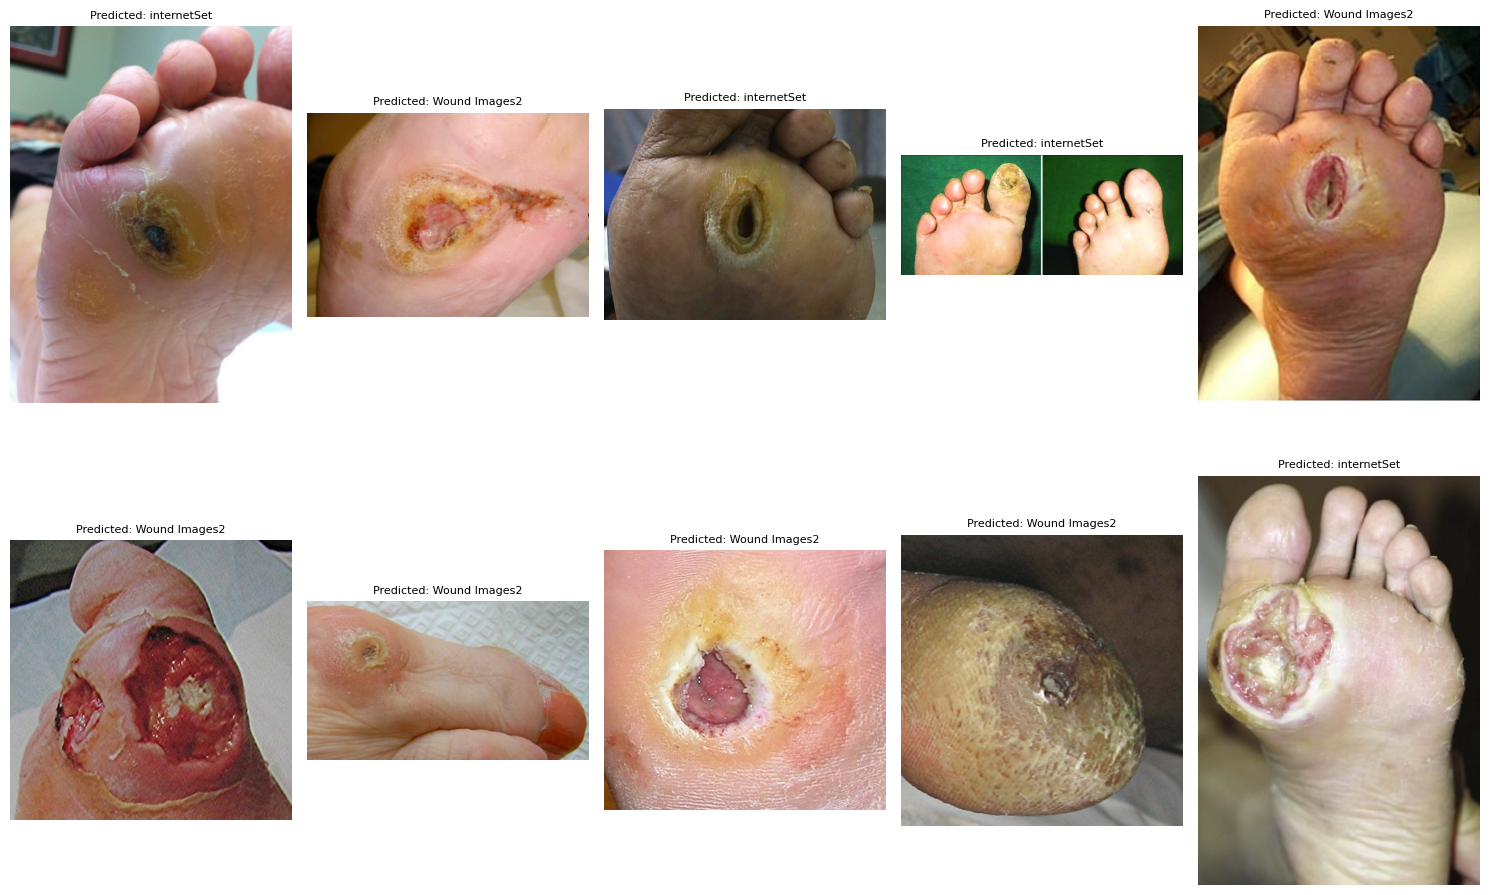


Note: Full evaluation metrics (accuracy, precision, recall, F1-score, confusion matrix) were not computed as ground truth labels for the TestSet were not inferable from its current structure.


In [19]:
import glob
from tensorflow.keras.preprocessing import image

# Load the best saved model
try:
    model = tf.keras.models.load_model('best_model.h5')
    print("Successfully loaded the best model from 'best_model.h5'")
except Exception as e:
    print(f"Could not load saved model: {e}. Using the current in-memory model for evaluation.")

# Get all image paths from the test_set_path
test_image_files = [os.path.join(test_set_path, f) for f in os.listdir(test_set_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
print(f"Found {len(test_image_files)} images in the test set directory for prediction.")

# Manually load and preprocess images for prediction
def load_and_preprocess_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch dimension
    img_array /= 255.0 # Normalize pixel values
    return img_array

all_test_images = []
original_test_images = [] # To store original images for display
for img_path in test_image_files:
    try:
        all_test_images.append(load_and_preprocess_image(img_path))
        original_test_images.append(Image.open(img_path))
    except Exception as e:
        print(f"Could not load or preprocess image {os.path.basename(img_path)}: {e}")

if all_test_images:
    test_images_array = np.vstack(all_test_images)
    print(f"Shape of all preprocessed test images array: {test_images_array.shape}")

    # Make predictions
    predictions = model.predict(test_images_array)
    predicted_classes_indices = np.argmax(predictions, axis=1)

    # Map predicted indices to class names from the training data
    # Ensure class_names is available from the training generator setup
    predicted_class_labels = [class_names[idx] for idx in predicted_classes_indices]

    print("\nSample Predictions on Test Set Images:")
    plt.figure(figsize=(15, 10))
    for i in range(min(10, len(test_image_files))): # Display up to 10 sample predictions
        plt.subplot(2, 5, i + 1)
        plt.imshow(original_test_images[i])
        plt.title(f"Predicted: {predicted_class_labels[i]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\nNote: Full evaluation metrics (accuracy, precision, recall, F1-score, confusion matrix) were not computed as ground truth labels for the TestSet were not inferable from its current structure.")
else:
    print("No valid test images found for prediction.")

Using the model already in memory.
Testing with sample image: bleeding-under-callus-preulcerative (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


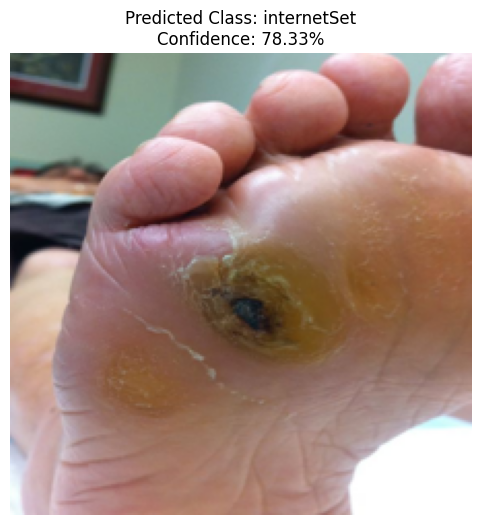

Predicted Class: internetSet
Confidence: 78.33%
All class probabilities: [0.01990751 0.17901896 0.78334147 0.01773203]
Class names: ['Wound Images', 'Wound Images2', 'internetSet', 'samples']


In [24]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load the best saved model if it's not already loaded
try:
    # We'll use the model already in memory from previous execution if it exists
    # If you restart runtime, you might need to reload it explicitly
    if 'model' not in locals() or not isinstance(model, tf.keras.Model):
        model = tf.keras.models.load_model('best_model.h5')
        print("Successfully loaded the best model from 'best_model.h5'")
    else:
        print("Using the model already in memory.")
except Exception as e:
    print(f"Could not load saved model: {e}. Please ensure 'best_model.h5' exists or run previous training cell.")

# Assuming test_image_files, IMG_HEIGHT, IMG_WIDTH, and class_names are defined from previous cells
# Use the first image from the test_image_files for demonstration
if test_image_files:
    sample_image_path = test_image_files[0]
    print(f"Testing with sample image: {os.path.basename(sample_image_path)}")

    # Manually load and preprocess the sample image
    def load_and_preprocess_single_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
        img = Image.open(img_path).convert('RGB')
        img = img.resize(target_size)
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = img_array / 255.0 # Normalize pixel values
        return img_array, img

    input_image_array, original_display_image = load_and_preprocess_single_image(sample_image_path)

    # Make prediction
    prediction_probabilities = model.predict(input_image_array)
    predicted_class_index = np.argmax(prediction_probabilities[0])
    predicted_class_label = class_names[predicted_class_index]
    confidence = np.max(prediction_probabilities[0]) * 100

    # Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(original_display_image)
    plt.title(f"Predicted Class: {predicted_class_label}\nConfidence: {confidence:.2f}%", fontsize=12)
    plt.axis('off')
    plt.show()

    print(f"Predicted Class: {predicted_class_label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"All class probabilities: {prediction_probabilities[0]}")
    print(f"Class names: {class_names}")

else:
    print("No test images found to perform sample prediction.")